# Testing `dataset_cache_794495.md` — can the instructions alone identify errors?

This notebook is a **literal execution of the markdown's instructions**, nothing more.
It loads only `dataset_cache_794495.pkl` (no image, no segmentation mask, no cloud
credentials — exactly the constraint the markdown promises) and tries to reproduce the
split / merge / omit identification using only what the markdown describes.

Each section corresponds to a section of the markdown. Cells `assert` the markdown's
explicit claims, so when you run top-to-bottom the output tells you, per claim, whether
the instruction was **sufficient and correct** or **misleading / incomplete**.

Kernel: **panda**.

## 0. Setup

The markdown says loading "requires the `agentic_neuron_proofreader` package on the path"
and can be done with a plain `pickle.load`. We add the package source to `sys.path` and
do exactly that.

In [1]:
import sys, os, pickle
from collections import defaultdict

import numpy as np
import networkx as nx

# The pickle stores `SkeletonGraph` instances, so the package must be importable.
REPO = "/allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent"
sys.path.insert(0, os.path.join(REPO, "agentic-neuron-proofreader/src"))

minlen = 10
CACHE_PATH = os.path.join(REPO, f"exa-spim-agent/dataset_cache_794495_mcl{minlen}.pkl")

# Track which markdown claims pass / fail so we can summarize at the end.
REPORT = []
def check(claim, ok, detail=""):
    REPORT.append((claim, bool(ok), detail))
    flag = "PASS" if ok else "FAIL"
    print(f"[{flag}] {claim}" + (f"  ->  {detail}" if detail else ""))
    return ok

## 1. Load the cache (markdown § "Loading the cache")

Markdown claims:
- the pickle is a single dict;
- the relevant keys are `anisotropy`, `min_cable_length`, `node_spacing`,
  `fragments_graph`, `gt_graph`;
- `anisotropy == (0.748, 0.748, 1.0)`, `node_spacing == 5`, and `min_cable_length`
  matches the value the cache was built with;
- a plain `pickle.load` works **without** touching the image / credentials.

In [2]:
with open(CACHE_PATH, "rb") as f:
    payload = pickle.load(f)   # markdown: requires agentic_neuron_proofreader importable

check("pickle is a single dict", isinstance(payload, dict), f"type={type(payload).__name__}")
print("keys:", list(payload.keys()))

gt_graph        = payload["gt_graph"]
fragments_graph = payload["fragments_graph"]
anisotropy      = payload["anisotropy"]

for k in ["anisotropy", "min_cable_length", "node_spacing", "fragments_graph", "gt_graph"]:
    check(f"key '{k}' present", k in payload)

check("anisotropy == (0.748, 0.748, 1.0)", tuple(np.round(anisotropy, 3)) == (0.748, 0.748, 1.0),
      str(tuple(anisotropy)))
check(f"min_cable_length == {minlen}", payload.get("min_cable_length") == minlen, str(payload.get("min_cable_length")))
check("node_spacing == 5", payload.get("node_spacing") == 5, str(payload.get("node_spacing")))

[PASS] pickle is a single dict  ->  type=dict
keys: ['fragments_path', 'gt_path', 'img_path', 'anisotropy', 'min_cable_length', 'node_spacing', 'fragments_graph', 'gt_graph']
[PASS] key 'anisotropy' present
[PASS] key 'min_cable_length' present
[PASS] key 'node_spacing' present
[PASS] key 'fragments_graph' present
[PASS] key 'gt_graph' present
[PASS] anisotropy == (0.748, 0.748, 1.0)  ->  (0.748, 0.748, 1.0)
[PASS] min_cable_length == 10  ->  10
[PASS] node_spacing == 5  ->  5


True

In [3]:
# Markdown sample code: graph summaries.
print(gt_graph.summary(prefix="GroundTruth"))
print(fragments_graph.summary(prefix="Fragments"))

GroundTruth Graph
# Connected Components: 19
# Nodes: 1,363,808
# Edges: 1,363,789
Memory Consumption: 346.41 GBs
Fragments Graph
# Connected Components: 478,611
# Nodes: 25,527,200
# Edges: 25,048,589
Memory Consumption: 346.41 GBs


## 2. Component counts (markdown § "Working with the graph")

A connected component in `gt_graph` is one traced neuron; in `fragments_graph`
it is one UNet fragment. The fragment count depends on the `min_cable_length`
used to build the cache, so we just report both counts.

In [4]:
n_gt   = nx.number_connected_components(gt_graph)
n_frag = nx.number_connected_components(fragments_graph)
print("GT components:  ", n_gt)
print("Frag components:", n_frag)

# A GT component is one traced neuron; a fragment component is one UNet fragment.
# (Fragment count depends on min_cable_length, so we report it rather than assert a range.)
check("both graphs have components to compare", n_gt > 0 and n_frag > 0,
      f"GT={n_gt}, frags={n_frag}")

GT components:   19
Frag components: 478611
[PASS] both graphs have components to compare  ->  GT=19, frags=478611


True

## 3. The GT / predicted namespace split (markdown § "SWC ID vs segment ID")

This is the subtle claim the markdown was corrected to make explicit:
- `node_segment_id` exists on **both** graphs (same class);
- on `gt_graph` it returns the **GT neuron's own name** `N0XX-794495-<initials>` — *not* a prediction;
- on `fragments_graph` it returns the **raw U-Net segment label** — the predicted identity;
- a GT node carries **no predicted label** until matched against `fragments_graph`.

If the markdown is right, the two graphs' segment-id namespaces should be disjoint in style.

In [5]:
gt_node = next(iter(gt_graph.nodes))
print("gt_graph.node_swc_id     :", gt_graph.node_swc_id(gt_node))
print("gt_graph.node_segment_id :", gt_graph.node_segment_id(gt_node))

frag_node = next(iter(fragments_graph.nodes))
print("fragments_graph.node_swc_id     :", fragments_graph.node_swc_id(frag_node))
print("fragments_graph.node_segment_id :", fragments_graph.node_segment_id(frag_node))

# Collect the distinct segment-id namespaces of each graph.
gt_segids   = {gt_graph.node_segment_id(n)   for n in gt_graph.nodes}
frag_segids = {fragments_graph.node_segment_id(n) for n in fragments_graph.nodes}

gt_named_like_neuron = all("794495" in s for s in gt_segids)
check("gt_graph segment ids look like GT neuron names (contain '794495')",
      gt_named_like_neuron, f"examples: {sorted(gt_segids)[:3]}")
check("GT and fragment segment-id namespaces are disjoint",
      gt_segids.isdisjoint(frag_segids),
      f"#gt_ids={len(gt_segids)}, #frag_ids={len(frag_segids)}, overlap={len(gt_segids & frag_segids)}")

gt_graph.node_swc_id     : N016-794495-HP.0
gt_graph.node_segment_id : N016-794495-HP
fragments_graph.node_swc_id     : 7362709551.0
fragments_graph.node_segment_id : 7362709551
[PASS] gt_graph segment ids look like GT neuron names (contain '794495')  ->  examples: ['N001-794495-JT', 'N002-794495-PP', 'N003-794495-SP']
[PASS] GT and fragment segment-id namespaces are disjoint  ->  #gt_ids=19, #frag_ids=478596, overlap=0


True

## 4. Label each GT node by nearest fragment segment (markdown § "Identifying errors", step 1)

Markdown step 1: for every GT node, query `fragments_graph.kdtree` for the nearest fragment
node; if within a tolerance ("~a few µm"), assign that fragment's **segment id** as the GT
node's predicted label; otherwise the node is unlabeled (`"0"`).

The tolerance is *not* a stored constant — the markdown only says "~a few µm". We make that
explicit here and treat it as the one free parameter the markdown leaves to the reader. This
is itself a test of whether the markdown is self-contained enough to act on.

In [6]:
MATCH_TOL_UM = 2.0   # markdown only says "~a few µm"; reader's choice. Flagged as a gap below.

# Vectorized nearest-fragment query over all GT nodes at once.
# node_xyz is (N,3) in (x,y,z) microns; kdtree is built over fragment node_xyz (same space).
gt_xyz = gt_graph.node_xyz                       # (N_gt, 3) microns
dists, nn_frag_nodes = fragments_graph.kdtree.query(gt_xyz)

# Map each nearest fragment node -> its U-Net segment id; threshold by tolerance.
gt_pred_label = {}
for gt_n in gt_graph.nodes:
    d = float(dists[gt_n])
    if d <= MATCH_TOL_UM:
        gt_pred_label[gt_n] = fragments_graph.node_segment_id(int(nn_frag_nodes[gt_n]))
    else:
        gt_pred_label[gt_n] = "0"   # unlabeled

n_labeled   = sum(1 for v in gt_pred_label.values() if v != "0")
n_unlabeled = sum(1 for v in gt_pred_label.values() if v == "0")
print(f"GT nodes total: {gt_graph.number_of_nodes()}")
print(f"  labeled (within {MATCH_TOL_UM} µm of a fragment): {n_labeled}")
print(f"  unlabeled (-> omit):                              {n_unlabeled}")
print(f"  median GT->fragment distance: {np.median(dists):.2f} µm")

check("step 1 runs: every GT node received a predicted label or '0'",
      len(gt_pred_label) == gt_graph.number_of_nodes(),
      f"{len(gt_pred_label)} labels for {gt_graph.number_of_nodes()} nodes")

GT nodes total: 1363808
  labeled (within 2.0 µm of a fragment): 982732
  unlabeled (-> omit):                              381076
  median GT->fragment distance: 1.57 µm
[PASS] step 1 runs: every GT node received a predicted label or '0'  ->  1363808 labels for 1363808 nodes


True

## 5. Classify each GT edge: omit / split / correct (markdown § "Identifying errors", step 2)

Markdown step 2, walking each GT edge `(i, j)`:
- **omit**  — both endpoints unlabeled (`"0"`);
- **split** — both labeled but the segment ids differ;
- **correct** — same nonzero segment id on both ends.

We report the % split / omit / correct edges.

In [7]:
n_omit = n_split = n_correct = 0
for i, j in gt_graph.edges:
    li, lj = gt_pred_label[i], gt_pred_label[j]
    if li == "0" and lj == "0":
        n_omit += 1
    elif li != "0" and lj != "0" and li != lj:
        n_split += 1
    elif li != "0" and lj != "0" and li == lj:
        n_correct += 1
    # (exactly one labeled / one unlabeled: boundary edge, counted as neither here)

E = gt_graph.number_of_edges()
print(f"GT edges: {E}")
print(f"  split edges:   {n_split:6d}  ({100*n_split/E:.2f} %)")
print(f"  omit edges:    {n_omit:6d}  ({100*n_omit/E:.2f} %)")
print(f"  correct edges: {n_correct:6d}  ({100*n_correct/E:.2f} %)")

check("step 2 runs: edges classified into omit/split/correct", E > 0,
      f"split={n_split}, omit={n_omit}, correct={n_correct}")

GT edges: 1363789
  split edges:      650  (0.05 %)
  omit edges:    204064  (14.96 %)
  correct edges: 804137  (58.96 %)
[PASS] step 2 runs: edges classified into omit/split/correct  ->  split=650, omit=204064, correct=804137


True

## 6. Count splits per neuron (markdown § "Identifying errors", step 3)

Markdown step 3: splits for a GT neuron = `(# distinct predicted segment ids touching it) − 1`.

In [8]:
# Group GT nodes by their GT neuron (its own segment id), collect predicted labels touching it.
neuron_to_pred_labels = defaultdict(set)
for gt_n in gt_graph.nodes:
    neuron = gt_graph.node_segment_id(gt_n)          # GT neuron name
    lab = gt_pred_label[gt_n]
    if lab != "0":
        neuron_to_pred_labels[neuron].add(lab)

splits_per_neuron = {n: max(len(labs) - 1, 0) for n, labs in neuron_to_pred_labels.items()}
total_splits = sum(splits_per_neuron.values())
avg_splits   = total_splits / max(len(splits_per_neuron), 1)

print(f"neurons with >=1 predicted label: {len(splits_per_neuron)}")
print(f"Total Splits: {total_splits}")
print(f"Avg. Splits per Neuron: {avg_splits:.1f}")
for n in sorted(splits_per_neuron)[:5]:
    print(f"   {n}: {splits_per_neuron[n]} splits")

check("step 3 runs: split counts produced per neuron", len(splits_per_neuron) > 0,
      f"total={total_splits}")

neurons with >=1 predicted label: 19
Total Splits: 3499
Avg. Splits per Neuron: 184.2
   N001-794495-JT: 87 splits
   N002-794495-PP: 151 splits
   N003-794495-SP: 259 splits
   N004-794495-JG: 324 splits
   N005-794495-HP: 229 splits
[PASS] step 3 runs: split counts produced per neuron  ->  total=3499


True

## 7. Detect merges (markdown § "Identifying errors", step 4)

Markdown step 4: a merge is a **single predicted segment id that maps onto two or more
distinct GT neurons**. The markdown's geometric description (walk a fragment, >~50 µm away,
re-approaches a different GT neuron) needs the mask to do exactly; with cache-only data we
test the *core* definition: one segment touching multiple GT neurons.

In [9]:
MERGE_DIST_UM = 50.0   # markdown's '> ~50 µm' threshold for merge reasoning

# For each predicted segment, which GT neurons does it land near (within MATCH_TOL_UM)?
pred_label_to_neurons = defaultdict(set)
for gt_n in gt_graph.nodes:
    lab = gt_pred_label[gt_n]
    if lab != "0":
        pred_label_to_neurons[lab].add(gt_graph.node_segment_id(gt_n))

merged_segments = {lab: neurons for lab, neurons in pred_label_to_neurons.items() if len(neurons) >= 2}
# A segment touching k GT neurons contributes (k-1) merge events (markdown step-3-style counting).
total_merges = sum(len(neurons) - 1 for neurons in merged_segments.values())

print(f"predicted segments touching >=2 GT neurons: {len(merged_segments)}")
print(f"Total Merges: {total_merges}")
for lab, neurons in list(merged_segments.items())[:5]:
    print(f"   segment {lab} merges: {sorted(neurons)}")

check("step 4 runs: merge candidates identified", isinstance(total_merges, int),
      f"segments={len(merged_segments)}, merges={total_merges}")

predicted segments touching >=2 GT neurons: 30
Total Merges: 33
   segment 5974668344 merges: ['N016-794495-HP', 'N017-794495-IG', 'N018-794495-YZ']
   segment 4318128366 merges: ['N007-794495-JG', 'N009-794495-MB', 'N020-794495-JG', 'N023-794495-JG']
   segment 7092944050 merges: ['N009-794495-MB', 'N023-794495-JG']
   segment 7093673513 merges: ['N009-794495-MB', 'N023-794495-JG']
   segment 7683788161 merges: ['N019-794495-SP', 'N020-794495-JG']
[PASS] step 4 runs: merge candidates identified  ->  segments=30, merges=33


True

## 7b. Visualize the errors

These plots render directly from the skeleton coordinates (`node_xyz`) and the
edge classification computed above — **cache-only, no image**. They make the
split / omit / correct labels visible so you can eyeball whether the markdown's
identification procedure is behaving sensibly.

Color convention used throughout:
- **green**  = correctly reconstructed GT edge (both ends share one predicted segment)
- **orange** = split edge (ends carry different predicted segments)
- **red**    = omit edge (neither end matched any fragment)
- **grey**   = boundary edge (exactly one end matched)

In [10]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import os

EDGE_COLORS = {"correct": "#2ca02c", "split": "#ff7f0e", "omit": "#d62728", "boundary": "#bbbbbb"}

def classify_edge(i, j):
    """Same logic as section 5, returned as a label for coloring."""
    li, lj = gt_pred_label[i], gt_pred_label[j]
    if li == "0" and lj == "0":
        return "omit"
    if li != "0" and lj != "0":
        return "correct" if li == lj else "split"
    return "boundary"

# Precompute (edge -> classification) once for all plots below.
edge_class = {(i, j): classify_edge(i, j) for i, j in gt_graph.edges}

def project(xyz):
    """node_xyz is (x, y, z) microns; plot the (x, y) projection."""
    return xyz[0], xyz[1]

legend_handles = [Line2D([0], [0], color=c, lw=2, label=k) for k, c in EDGE_COLORS.items()]

FIGS_DIR = os.path.join(os.path.dirname(CACHE_PATH), "..", "notebooks", "figs_markdown_test")
os.makedirs(FIGS_DIR, exist_ok=True)
print("figures will be saved to:", os.path.abspath(FIGS_DIR))

figures will be saved to: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/notebooks/figs_markdown_test


### Plot 1 — whole-brain GT skeletons colored by error type

Every GT edge drawn in the (x, y) projection, colored by its classification.
Orange clusters = where the automated reconstruction splits a neuron; red = missed
stretches; green = recovered.

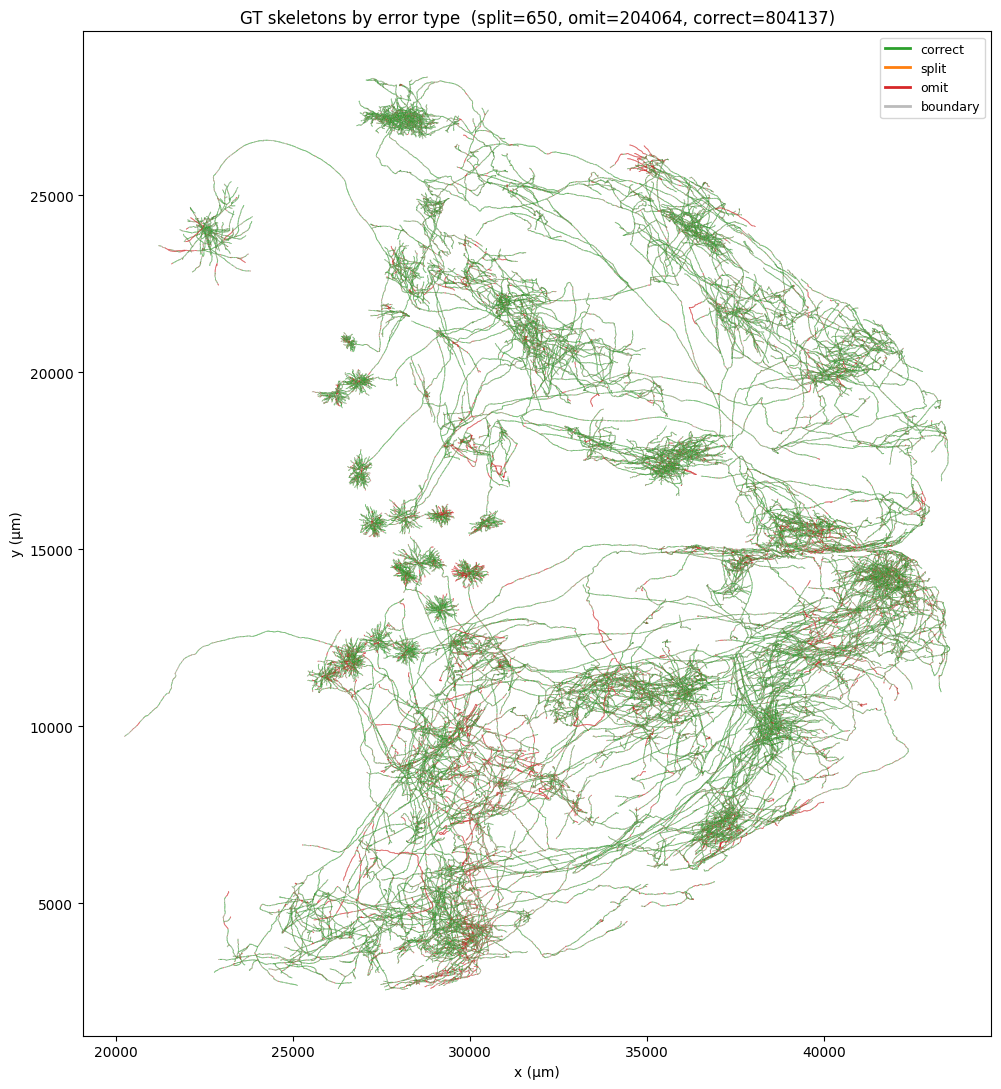

In [11]:
segs, cols = [], []
for (i, j), cls in edge_class.items():
    (xi, yi), (xj, yj) = project(gt_graph.node_xyz[i]), project(gt_graph.node_xyz[j])
    segs.append([(xi, yi), (xj, yj)])
    cols.append(EDGE_COLORS[cls])

fig, ax = plt.subplots(figsize=(11, 11))
ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.6))
ax.autoscale(); ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"GT skeletons by error type  (split={n_split}, omit={n_omit}, correct={n_correct})")
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "01_wholebrain_error_types.png"), dpi=150)
plt.show()

### Plot 2 — per-neuron error breakdown

Stacked bar of correct / split / omit / boundary edge counts for each of the 18
GT neurons. Shows how unevenly errors distribute across neurons (the markdown's
'error rates vary by morphology/annotator' point).

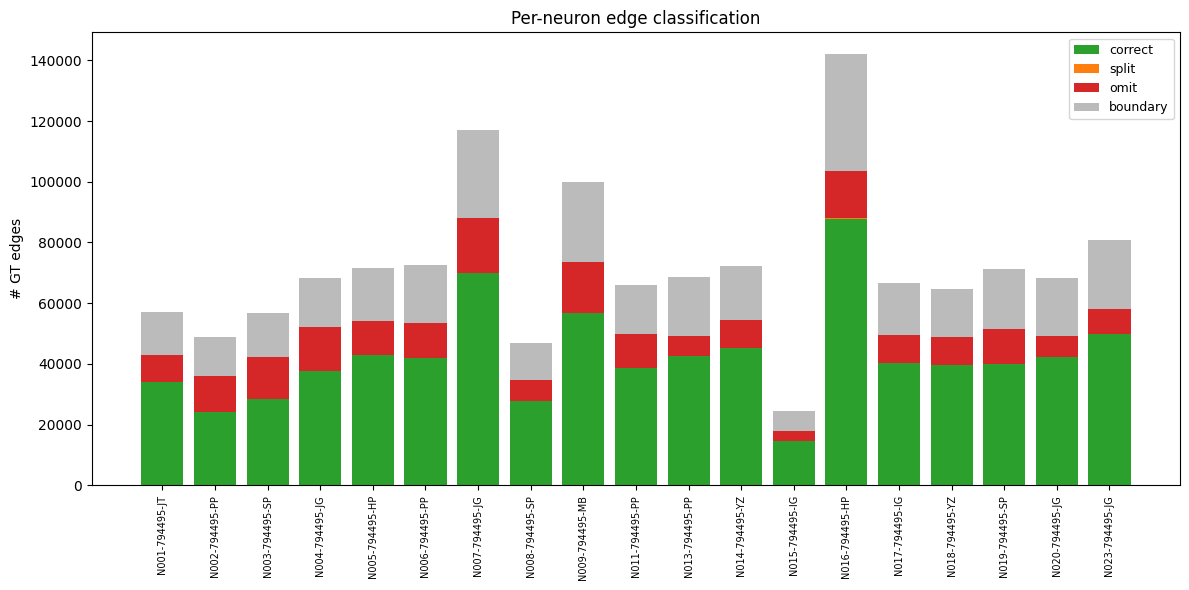

In [12]:
per_neuron = defaultdict(lambda: defaultdict(int))
for (i, j), cls in edge_class.items():
    neuron = gt_graph.node_segment_id(i)   # both endpoints share a GT neuron (same component)
    per_neuron[neuron][cls] += 1

neurons = sorted(per_neuron)
order = ["correct", "split", "omit", "boundary"]
counts = {c: [per_neuron[n][c] for n in neurons] for c in order}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(neurons))
for c in order:
    vals = np.array(counts[c])
    ax.bar(range(len(neurons)), vals, bottom=bottom, color=EDGE_COLORS[c], label=c)
    bottom += vals
ax.set_xticks(range(len(neurons)))
ax.set_xticklabels(neurons, rotation=90, fontsize=7)
ax.set_ylabel("# GT edges"); ax.set_title("Per-neuron edge classification")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "02_per_neuron_breakdown.png"), dpi=150)
plt.show()

In [13]:
# Per-neuron error distribution (text log of the same counts plotted above).
# For each GT neuron: edge counts by class, the % of its edges in each class,
# and the split count (distinct predicted segments touching it - 1).
print(f"{'neuron':<18}{'edges':>8}{'correct':>9}{'split':>7}{'omit':>7}{'bound':>7}"
      f"{'%corr':>7}{'%split':>8}{'%omit':>7}{'#splits':>9}")
print("-" * 96)
for n in neurons:
    c = per_neuron[n]
    tot = sum(c[k] for k in order)
    nsplit = splits_per_neuron.get(n, 0)   # from section 6
    print(f"{n:<18}{tot:>8}{c['correct']:>9}{c['split']:>7}{c['omit']:>7}{c['boundary']:>7}"
          f"{100*c['correct']/tot:>6.1f}%{100*c['split']/tot:>7.1f}%{100*c['omit']/tot:>6.1f}%"
          f"{nsplit:>9}")

# Totals across all neurons.
tot_all = {k: sum(per_neuron[n][k] for n in neurons) for k in order}
grand = sum(tot_all.values())
print("-" * 96)
print(f"{'ALL':<18}{grand:>8}{tot_all['correct']:>9}{tot_all['split']:>7}"
      f"{tot_all['omit']:>7}{tot_all['boundary']:>7}"
      f"{100*tot_all['correct']/grand:>6.1f}%{100*tot_all['split']/grand:>7.1f}%"
      f"{100*tot_all['omit']/grand:>6.1f}%{sum(splits_per_neuron.values()):>9}")

neuron               edges  correct  split   omit  bound  %corr  %split  %omit  #splits
------------------------------------------------------------------------------------------------
N001-794495-JT       57169    34016     21   8745  14387  59.5%    0.0%  15.3%       87
N002-794495-PP       48860    24098     22  11764  12976  49.3%    0.0%  24.1%      151
N003-794495-SP       56735    28344     29  13872  14490  50.0%    0.1%  24.5%      259
N004-794495-JG       68338    37559     54  14603  16122  55.0%    0.1%  21.4%      324
N005-794495-HP       71420    42873     42  11155  17350  60.0%    0.1%  15.6%      229
N006-794495-PP       72595    41797     45  11470  19283  57.6%    0.1%  15.8%      205
N007-794495-JG      117027    69771     44  18086  29126  59.6%    0.0%  15.5%      236
N008-794495-SP       46903    27882     20   6619  12382  59.4%    0.0%  14.1%      119
N009-794495-MB       99882    56850     69  16568  26395  56.9%    0.1%  16.6%      282
N011-794495-PP       65

### Plot 3 — zoom on a single split, with the fragments that cause it

Pick the GT neuron with the most split edges, draw it colored by error type, and
overlay (in thin black) the UNet fragment skeletons in the same region. The break
between fragment colors is exactly the split the markdown procedure flags.

focus neuron: N009-794495-MB  (69 split edges)


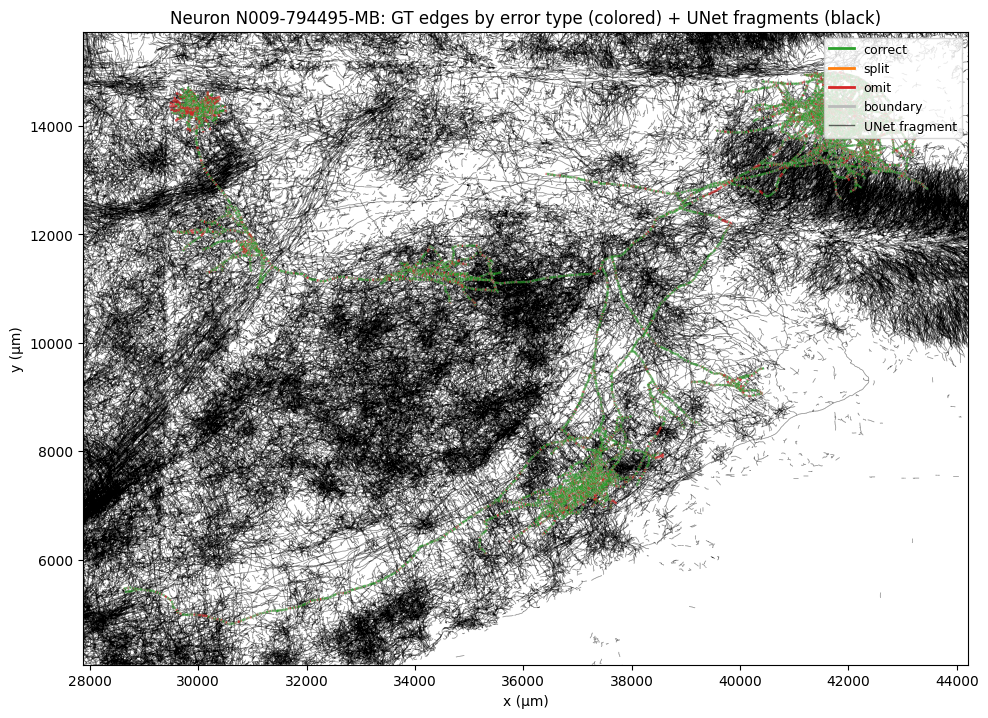

In [14]:
# Choose the GT neuron with the most split edges.
split_by_neuron = {n: per_neuron[n]["split"] for n in neurons}
focus = max(split_by_neuron, key=split_by_neuron.get)
focus_nodes = [n for n in gt_graph.nodes if gt_graph.node_segment_id(n) == focus]
fxyz = gt_graph.node_xyz[focus_nodes]
xmin, ymin = fxyz[:, 0].min(), fxyz[:, 1].min()
xmax, ymax = fxyz[:, 0].max(), fxyz[:, 1].max()
pad = 0.05 * max(xmax - xmin, ymax - ymin) + 1
print(f"focus neuron: {focus}  ({split_by_neuron[focus]} split edges)")

fig, ax = plt.subplots(figsize=(10, 10))

# GT edges of the focus neuron, colored by error type.
fsegs, fcols = [], []
for (i, j), cls in edge_class.items():
    if gt_graph.node_segment_id(i) == focus:
        (xi, yi), (xj, yj) = project(gt_graph.node_xyz[i]), project(gt_graph.node_xyz[j])
        fsegs.append([(xi, yi), (xj, yj)]); fcols.append(EDGE_COLORS[cls])
ax.add_collection(LineCollection(fsegs, colors=fcols, linewidths=1.6, zorder=3))

# Overlay fragment skeletons that fall in this bounding box (thin black).
fx = fragments_graph.node_xyz
in_box = (fx[:, 0] >= xmin - pad) & (fx[:, 0] <= xmax + pad) & \
         (fx[:, 1] >= ymin - pad) & (fx[:, 1] <= ymax + pad)
in_box_nodes = set(np.where(in_box)[0].tolist())
frag_segs = []
for i, j in fragments_graph.edges:
    if i in in_box_nodes and j in in_box_nodes:
        (xi, yi), (xj, yj) = project(fragments_graph.node_xyz[i]), project(fragments_graph.node_xyz[j])
        frag_segs.append([(xi, yi), (xj, yj)])
ax.add_collection(LineCollection(frag_segs, colors="black", linewidths=0.5, alpha=0.5, zorder=1))

ax.set_xlim(xmin - pad, xmax + pad); ax.set_ylim(ymin - pad, ymax + pad)
ax.set_aspect("equal"); ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"Neuron {focus}: GT edges by error type (colored) + UNet fragments (black)")
ax.legend(handles=legend_handles + [Line2D([0], [0], color="black", lw=1, alpha=0.6, label="UNet fragment")],
          loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "03_split_zoom.png"), dpi=150)
plt.show()

## 8. Verdict — is the markdown useful?

Summarizes every claim checked above. The point is whether a reader, **using only
the markdown**, can:
1. load the cache,
2. recover the right comparison key (predicted segment id, not component),
3. label GT nodes and classify edges,
4. produce split/merge counts.

Any FAIL below points to an instruction that is incomplete or misleading and
should be fixed in the markdown.

In [15]:
print("=" * 72)
n_pass = sum(1 for _, ok, _ in REPORT if ok)
for claim, ok, detail in REPORT:
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")
print("=" * 72)
print(f"{n_pass}/{len(REPORT)} markdown claims verified from cache-only data.")
print()
print("KNOWN LIMITATIONS the markdown should make explicit (gaps surfaced by this test):")
print("  - The GT->fragment match tolerance ('~a few µm') is not a stored constant;")
print("    results (esp. % omit) depend on the MATCH_TOL_UM chosen above.")
print("  - Canonical scoring reads the dense segmentation MASK at each GT voxel; the")
print("    cache has only skeletons, so nearest-fragment-segment-id is a proxy. Fragments")
print("    shorter than min_cable_length were dropped, inflating apparent omits.")
print("  - Merge detection here tests the core definition (one segment -> many GT neurons);")
print("    the full geometric merge-site walk needs the mask.")

  [PASS] pickle is a single dict
  [PASS] key 'anisotropy' present
  [PASS] key 'min_cable_length' present
  [PASS] key 'node_spacing' present
  [PASS] key 'fragments_graph' present
  [PASS] key 'gt_graph' present
  [PASS] anisotropy == (0.748, 0.748, 1.0)
  [PASS] min_cable_length == 10
  [PASS] node_spacing == 5
  [PASS] both graphs have components to compare
  [PASS] gt_graph segment ids look like GT neuron names (contain '794495')
  [PASS] GT and fragment segment-id namespaces are disjoint
  [PASS] step 1 runs: every GT node received a predicted label or '0'
  [PASS] step 2 runs: edges classified into omit/split/correct
  [PASS] step 3 runs: split counts produced per neuron
  [PASS] step 4 runs: merge candidates identified
16/16 markdown claims verified from cache-only data.

KNOWN LIMITATIONS the markdown should make explicit (gaps surfaced by this test):
  - The GT->fragment match tolerance ('~a few µm') is not a stored constant;
    results (esp. % omit) depend on the MATCH_TOL_